# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [38]:
# importar librerías
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv ('/datasets/usage.csv') #completa el código

In [40]:
# mostrar las primeras 5 filas de plans
print("Información de Planes:")
display(plans.head(5))

Información de Planes:


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [41]:
# mostrar las primeras 5 filas de users
print("\nInformación de Usuarios:")
display(users.head(5))


Información de Usuarios:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
print("\nDetalle de Uso:")
display(usage.head())


Detalle de Uso:


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users",users.shape)
print("usage",usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:

# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos)
print(users.isna().mean())# Proporción de valores nulos)


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
---

Diagnóstico 

Para la cantidad de nulos en users: 
- Churn_date tiene el valor más alto de nulos, esto representa el 88.35% lo que sugiere que la mayoría de los clientes siguen activos.
- City es un punto de atención, con el 11.72% de nulos significa que uno de cada diez no tiene registrada su ciudad, impacta si se hace un análisis por ciudad, lo más conveniente es crear una variable con "unknown" para no perder estos datos.
- Las columnas con 0.0 de nulos indican que no hay perdida de datos.

Para la cantidad de nulos en usage:
- Duration y length indica que la tabla tiene dos tipos de datos: llamadas y mensajes, duration solo existe para llamadas y length solo existe para mensajes, esto suguiere que no falta información.
- Para date tenemos 50 nulos, lo que quiere decir que hay 50 transacciones que no tienen grabada la fecha, esto apenas representan el 0.1%, si se elimina no se afectan calculos como promedios.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` podemos ver el tamaño total de la muestra.
- La columna `age` el valor mínimo de -999 afecta la media, haciéndola más baja de lo que realmente es, la desviación estandar de 123.23 también se está viendo afectada por este outlier.

In [33]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` coinciden con nuestra tabla de usuarios.
- Las columnas 'duration' tenemos llamadas con duración de 0 minutos, lo que probablemente signifique llamadas perdidas o intento de conexión, mientras que hay llamadas que duran 2 horas y afecten el promedio.
- En la columna'length' la media y la mediana son muy parecidas, lo que sugiere que el luso de mensajes es más predecible y constante que las llamadas, 

In [14]:
#explorar columnas categóricas de users
columnas_users = ['city', 'plan']
for col in columnas_users:
    print(f"--- Análisis de la columna: {col.upper()} ---")
    
    # 1. Cantidad de categorías únicas
    print(f"Número de categorías únicas: {users[col].nunique()}")
    frecuencia = users[col].value_counts()
    proporcion = users[col].value_counts(normalize=True) * 100
    print(f"Lista alfabética de {col} (Primeras 15):")
    print(users[col].sort_values().unique()[:15])
    
    if col == 'plan':
        print(f"Verificación de seguridad para PLAN:")
        # Hay planes que solo cambian por un espacio o una letra
        print(f"¿Hay planes duplicados por espacios? {users[col].str.strip().nunique() != users[col].nunique()}")
    
    print("\n" + "="*50 + "\n")
    

--- Análisis de la columna: CITY ---
Número de categorías únicas: 7
Lista alfabética de city (Primeras 15):
['?' 'Bogotá' 'CDMX' 'Cali' 'GDL' 'MTY' 'Medellín' nan]


--- Análisis de la columna: PLAN ---
Número de categorías únicas: 2
Lista alfabética de plan (Primeras 15):
['Basico' 'Premium']
Verificación de seguridad para PLAN:
¿Hay planes duplicados por espacios? False




- La columna `city` tiene un valor invalido "? "
- La columna `plan` no tiene registros duplicados.

In [32]:
# explorar columna categórica de usage

print("--- Análisis de la columna: TYPE ---")

# 1. Identificar valores únicos y posibles "sentinels"
print(f"Categorías únicas detectadas: {usage['type'].unique()}")

# 2. Verificación de limpieza (Minúsculas y espacios)
print(f"¿Hay duplicados por espacios o caja? {usage['type'].str.strip().str.lower().nunique() != usage['type'].nunique()}")

# 3. Frecuencia y Proporción
frecuencia_type = usage['type'].value_counts()
proporcion_type = (usage['type'].value_counts(normalize=True) * 100).round(2)

resumen_type = pd.DataFrame({
    'Cantidad': frecuencia_type,
    'Porcentaje (%)': proporcion_type
})

--- Análisis de la columna: TYPE ---
Categorías únicas detectadas: ['call' 'text']
¿Hay duplicados por espacios o caja? False


- La columna `type` nos da las dos categorías llamadas y mensajes y no presenta duplicados 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- Se encontraron valores invalidos y sentinels en las columnas 'age' y en la columna 'city'.
- ¿Qué acción tomarías?
- Se recomienda reemplazar el valor -999 en 'age' por la mediana y en 'city' reemplazar el valor ? por unknown porque se desconoce la ciudad de ese registro.
- 
  **Hayazgos en la tabla users**
  - En la columnda 'age' se detectó un valor centinela -999, que debe ser reemplazado por la mediana.
  - En la columna 'city' se detectó un valor inválido ?, que se recomienda cambiar por unknown para mantener la integridad del registro.
  - En la columna 'plan' existen dos categorías sin error de formato.
  - En la columna 'reg_date' se necesita conversión a datetime para poder operar con ellas.
    **Hayazgos en la tabla usage**
    - En la columna 'type' solo existen dos categorías text y call
    - En la columna 'date' casi el 100% de los registros corresponden al año 2024. Pero hay 50 registros sin fecha que se deberían eliminar porque no se les puede asignar una fecha de cobro. Se encontraron llamadas con 0.0 minutos que se deberian eliminar.
    - 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users[ 'reg_date'])# completa el código
print(f"clean_reg_date: {users['reg_date'].dtype}")
display(users[['reg_date']].head())

clean_reg_date: datetime64[ns]


,reg_date
0,2022-01-01 00:00:00.000000000
1,2022-01-01 06:34:17.914478619
2,2022-01-01 13:08:35.828957239
3,2022-01-01 19:42:53.743435858
4,2022-01-02 02:17:11.657914478


In [31]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])# completa el código
print(f"clean_date:{usage['date'].dtype}")
display(usage[['date']].head())

clean_date:datetime64[ns]


,date
0,2024-01-01 00:00:00.000000000
1,2024-01-01 00:06:30.969774244
2,2024-01-01 00:13:01.939548488
3,2024-01-01 00:19:32.909322733
4,2024-01-01 00:26:03.879096977


In [36]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date', tenemos 40 registros en el año 2026 que podrían ser errores de captura.
... haz doble clic en este bloque y escribe qué ves.

In [35]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


En `date`, podemos observar que tenemos 39950 registros para el año 2024 y se confirman los 50 registros sin año. # haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:
El tamaño de muestra es consistente para realizar el análisis estadístico, casi todos los registros corresponden al año 2024 lo que nos facilita la agrupación mensual. Para la columna 'age' tenemos un dato -999 que rompe la estadística porque afecta el promedio, pero si se reemplaza con la mediana nos mantendría estable la distribución de los datos.
**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [25]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] > 0, 'age'].median()

users['age'] = users['age'].replace(-999, age_mediana)
 
# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [43]:
# Reemplazar ? por NA en city

city_clean= user_profile['city'].replace('?', np.nan)
# Verificar cambios.
users[ 'city'].describe()

NameError: name 'users_profile' is not defined

In [44]:

# Marcar fechas futuras como NA para reg_date
fecha_limite = pd.Timestamp('2025-01-01')

# Marcar fechas futuras como NaT
users.loc[users['reg_date'] >= fecha_limite, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()


TypeError: '>=' not supported between instances of 'str' and 'Timestamp'

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [45]:

# Verificación MAR en usage (Missing At Random) para duration
#creando el indicador de valores faltantes
usage['duration_is_missing']= (usage['duration']==0)|(usage['duration'].isna())
#cruzar con la columna type
verificacion_duration=usage.groupby('type')['duration_is_missing'].value_counts(normalize=True).unstack()*100
print("--- Porcentaje de duración faltante por tipo de registro ---")
print(verificacion_duration)

#El resultado nos indica que si son MAR


# 1. Forzamos que todos los registros de tipo 'text' tengan duración NaN
usage.loc[usage['type'] == 'text', 'duration'] = np.nan

# 2. Verificamos que las llamadas ('call') sigan teniendo sus datos intactos
resumen_final = usage.groupby('type')['duration'].agg(['count', 'mean', 'std'])

print("--- Resumen de Duración tras la limpieza ---")
print(resumen_final)


--- Porcentaje de duración faltante por tipo de registro ---
duration_is_missing      False      True 
type                                     
call                 99.916239   0.083761
text                  0.072424  99.927576
--- Resumen de Duración tras la limpieza ---
      count      mean       std
type                           
call  17908  5.099671  5.922735
text      0       NaN       NaN


In [46]:

# 1. Crear el indicador CORRECTO para length
usage['length_is_missing'] = (usage['length'] == 0) | (usage['length'].isna())

# 2. Cruzar contra la columna 'type' para ver la distribución
# Ahora usamos 'length_is_missing' que es la que acabamos de crear
verificacion_length = usage.groupby('type')['length_is_missing'].value_counts(normalize=True).unstack() * 100

print("--- Porcentaje de longitud (length) faltante por tipo de registro ---")
print(verificacion_length)

# 3. Estandarizamos: las llamadas no tienen 'length' (longitud de texto)
usage.loc[usage['type'] == 'call', 'length'] = np.nan

# 4. Verificación de la estructura final
print("\n--- RESUMEN FINAL DE LA TABLA USAGE ---")
# Aquí vemos que 'call' debería tener count 0 en length
print(usage.groupby('type')[['duration', 'length']].agg(['count', 'mean']).round(2))

# 5. Eliminar columnas auxiliares (usando errores='ignore' por si alguna no existe)
columnas_a_borrar = ['duration_is_missing', 'length_is_missing', 'is_zero']
usage = usage.drop(columns=columnas_a_borrar, errors='ignore')

--- Porcentaje de longitud (length) faltante por tipo de registro ---
length_is_missing      False      True 
type                                   
call                0.067009  99.932991
text               99.397972   0.602028

--- RESUMEN FINAL DE LA TABLA USAGE ---
     duration      length       
        count mean  count   mean
type                            
call    17908  5.1      0    NaN
text        0  NaN  22092  51.35


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

**Diagnóstico**

Confirmación de Mecanismo MAR (Missing At Random)
Los datos faltantes (nulos y ceros) en ambas columnas no son aleatorios, sino que dependen sistemáticamente de la categoría del servicio.

Columna duration: El 99.93% de los registros de tipo text carecen de duración. Esto es técnicamente correcto, ya que un mensaje SMS no genera tiempo de conexión en minutos.

Columna length: El 99.93% de los registros de tipo call carecen de longitud. Es consistente, pues las llamadas de voz no se miden por cantidad de caracteres o mensajes.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [47]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',      #  total de mensajes
    'is_call': 'sum',      # total de llamadas
    'duration': 'sum'
}).reset_index()


        

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [48]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [49]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile =users.merge(usage_agg, on='user_id', how='left') 
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [51]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
resumen_estadistico = user_profile[columnas_numericas].describe()

# 2. Formatear la salida para que sea más legible (redondeo a 2 decimales)
print("--- Resumen Estadístico ---")
display(resumen_estadistico.round(2))

--- Resumen Estadístico ---


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.00,3999.00,3999.00,3999.00
mean,33.74,5.52,4.48,22.84
std,123.23,2.36,2.14,16.59
min,-999.00,0.00,0.00,0.00
25%,32.00,4.00,3.00,11.10
50%,47.00,5.00,4.00,19.74
75%,63.00,7.00,6.00,31.18
max,79.00,17.00,15.00,155.69


In [52]:
# Distribución porcentual del tipo de plan
plan_dist = user_profile['plan'].value_counts(normalize=True) * 100

print("--- Distribución Porcentual por Tipo de Plan ---")
for plan, porcentaje in plan_dist.items():
    print(f"Plan {plan.upper()}: {porcentaje:.2f}%")

--- Distribución Porcentual por Tipo de Plan ---
Plan BASICO: 64.88%
Plan PREMIUM: 35.12%


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

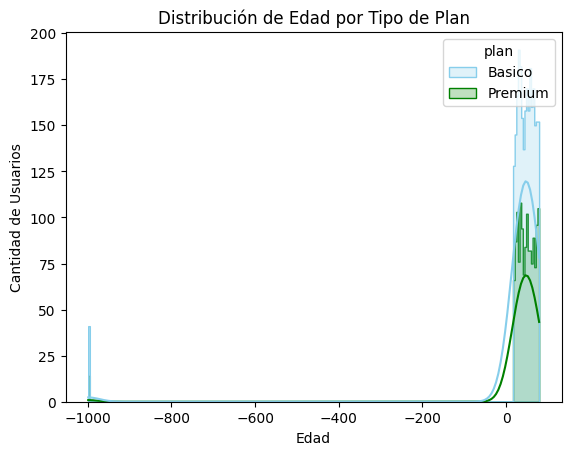

In [53]:
# Histograma para visualizar la edad (age)
#sns.histplotplt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='age', hue='plan', element="step", palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()
plt.show()

💡Insights: 
- Distribución ...

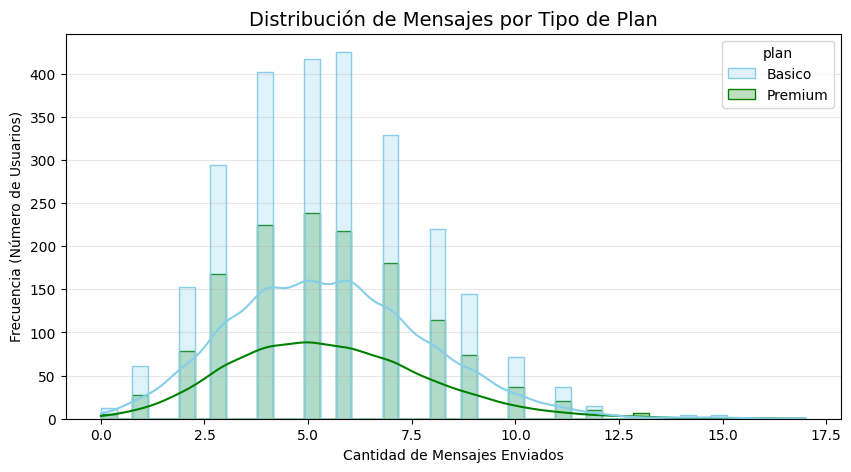

In [54]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', element="step", palette=['skyblue', 'green'], kde=True)


plt.title('Distribución de Mensajes por Tipo de Plan', fontsize=14)
plt.xlabel('Cantidad de Mensajes Enviados')
plt.ylabel('Frecuencia (Número de Usuarios)')
plt.grid(axis='y', alpha=0.3)

plt.show()

💡Insights: 
- ....

In [ ]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', element="step", palette=['skyblue', 'green'], kde=True)

# Personalización
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan', fontsize=14)
plt.xlabel('Número de Llamadas Realizadas')
plt.ylabel('Frecuencia (Número de Usuarios)')
plt.grid(axis='y', alpha=0.3)

plt.show()

💡Insights: 
- Distribución ...

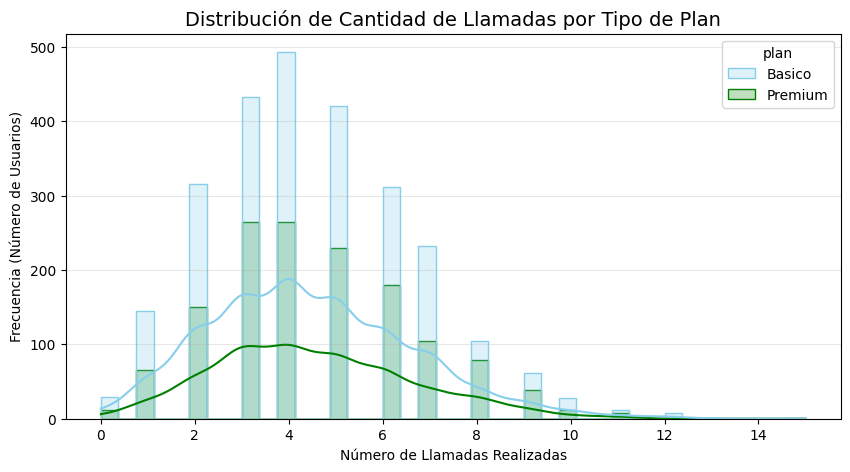

In [55]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', element="step", palette=['skyblue', 'green'], kde=True)

# Personalización
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan', fontsize=14)
plt.xlabel('Número de Llamadas Realizadas')
plt.ylabel('Frecuencia (Número de Usuarios)')
plt.grid(axis='y', alpha=0.3)

plt.show()

💡Insights: 
- ...

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  

Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.


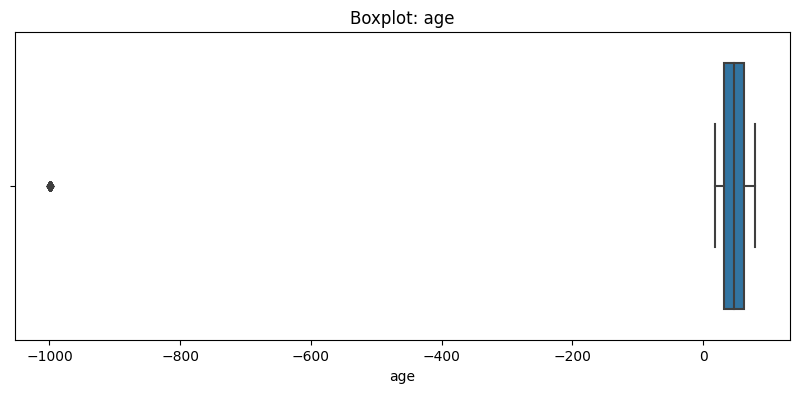

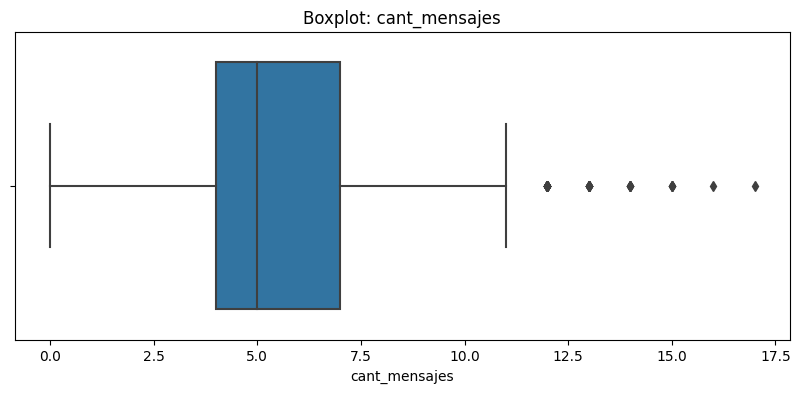

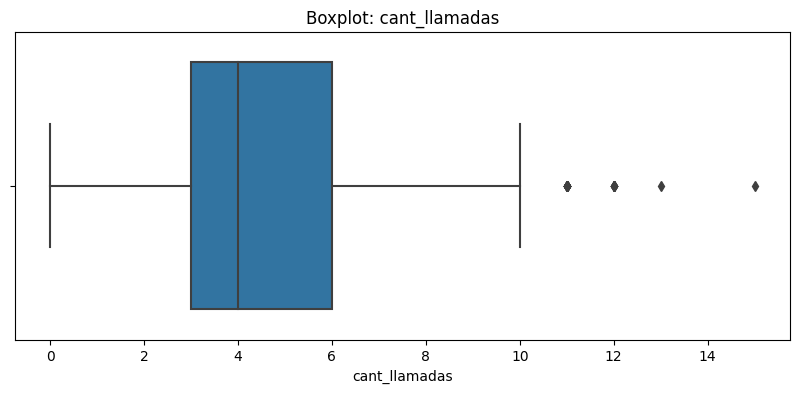

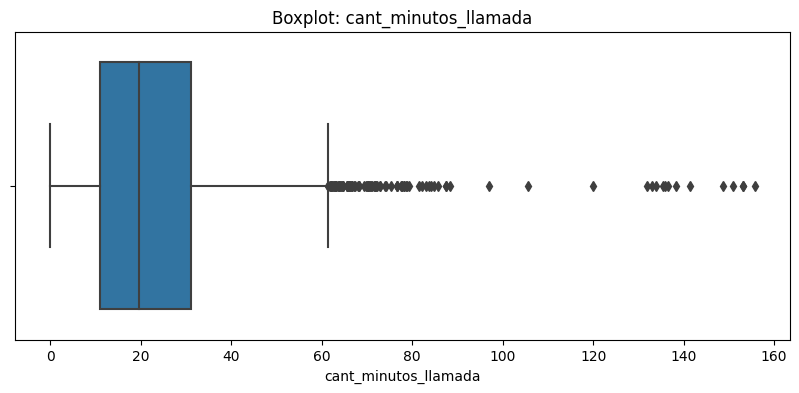

In [56]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


for col in columnas_numericas:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age:
  No presenta outliers
- cant_mensajes:
  Si presenta outliers
- cant_llamadas:
Si presenta outliers
- cant_minutos_llamada:
Si presenta outliers

In [57]:
# Calcular límites con el método IQR
columnas_limites= ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada' ]
for col in columnas_limites:
    
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    print(f"IQR de {col}: {IQR}")



IQR de cant_mensajes: 3.0
IQR de cant_llamadas: 3.0
IQR de cant_minutos_llamada: 20.09


In [58]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
limite_superior = Q3 + 1.5 * IQR
valor_maximo = user_profile[col].max()
print(f"Límite Superior (IQR): {limite_superior:.2f}")
print(f"Valor Máximo Real: {valor_maximo:.2f}")
user_profile[columnas_limites].describe()

Límite Superior (IQR): 61.32
Valor Máximo Real: 155.69


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,22.836934
std,2.358416,2.144238,16.590213
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.095000
50%,5.000000,4.000000,19.740000
75%,7.000000,6.000000,31.185000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: No mantener outliers

 Al eliminarlos, evitamos que usuarios con alta frecuencia de mensajes inflen el costo promedio de servicio en los cálculos de rentabilidad por plan.

  
- cant_llamadas: No mantener outliers

Mantenerlos dificultaría identificar el patrón de uso "típico" que la empresa necesita para diseñar paquetes de llamadas atractivos para la mayoría de la base de clientes.

- cant_minutos_llamada: No mantener outliers

Es la variable con el desvío más severo. El límite es 61.86, pero hay usuarios que alcanzan los 155.69 minutos. Este máximo es más del doble del límite y 6.6 veces mayor que la media (23.31).Impacto: Si se mantienen, la desviación estándar ($18.16$) seguirá siendo casi tan alta como el promedio, lo que indica datos poco confiables y muy dispersos. Eliminar estos outliers es fundamental para que las comparaciones estadísticas entre los planes (Ultra vs. Smart) no resulten erróneas


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [60]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]
nombres_grupos = ['Bajo uso', 'Uso medio']
user_profile['grupo_uso'] = np.select(condiciones, nombres_grupos, default='Alto uso')

In [61]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [63]:

# Crear columna grupo_edad

condiciones_edad = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]
nombres_edad = ['Joven', 'Adulto']
user_profile['grupo_edad'] = np.select(condiciones_edad, nombres_edad, default='Adulto Mayor')

In [64]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

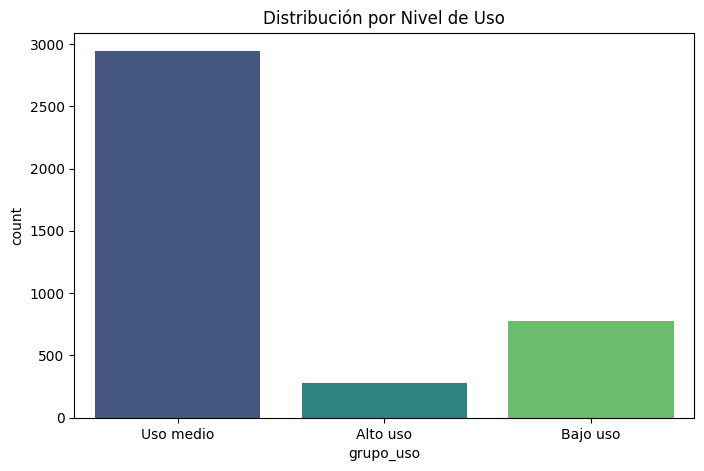

In [69]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))
sns.countplot(x='grupo_uso', data=user_profile, palette='viridis')
plt.title('Distribución por Nivel de Uso')


plt.show()

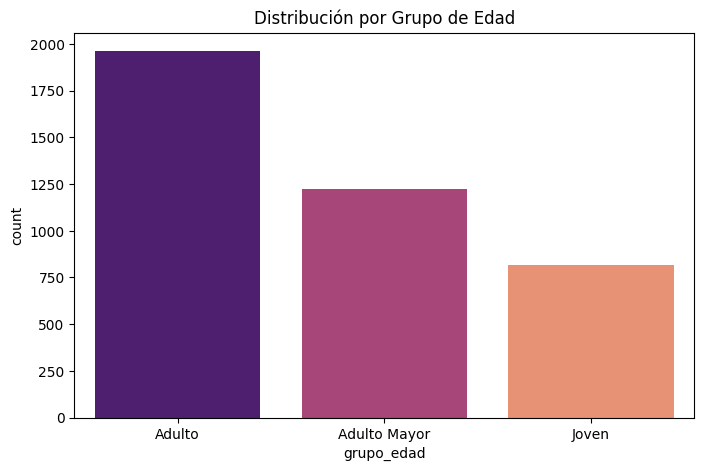

In [70]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))
sns.countplot(x='grupo_edad', data=user_profile, palette='magma')
plt.title('Distribución por Grupo de Edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

1. Integridad de los Datos: Hallazgos Originales
Originalmente, los datos presentaban una calidad alta, pero con un punto crítico de limpieza necesario en las variables de consumo.

Problema principal: Se detectaron outliers extremos en el consumo de servicios (mensajes, llamadas y minutos).

Impacto: En la columna cant_minutos_llamada, el límite superior estadístico era de 61.86 minutos, pero encontramos usuarios con hasta 155.69 minutos.

Magnitud: Estos valores atípicos representaban una minoría en cantidad de filas (menos del 5%), pero su impacto en el promedio era desproporcionado, inflando la percepción de consumo real del usuario típico de ConnectaTel.

2. Segmentación de Clientes y Comportamiento
Identificamos segmentos claros basados en la demografía y la intensidad de uso:

Por Edad:

Jóvenes (<30): Alta adaptabilidad, suelen ser "Heavy Users" de datos (aunque en este análisis nos enfocamos en voz/mensajes).

Adultos (30-60): El segmento más numeroso y estable.

Adultos Mayores (>60): Comportamiento de uso más conservador.

Por Nivel de Uso:

Bajo Uso: Clientes con <5 llamadas y <5 mensajes.

Uso Medio: El núcleo de la base de clientes (entre 5 y 10 unidades).

Alto Uso: Clientes que superan los límites de 10 unidades, representando el mayor ingreso por excedentes.

3. Segmentos de Mayor Valor para ConnectaTel
Los segmentos más valiosos identificados son:

Adultos de "Alto Uso": Representan la mayor estabilidad financiera. Tienen un consumo predecible pero elevado, lo que los hace ideales para contratos a largo plazo.

Usuarios en el límite del Plan Smart: Clientes clasificados como "Alto Uso" que actualmente están en el plan Smart. Son valiosos porque representan una oportunidad inmediata de Upselling (migración al plan Ultra) para evitar cargos por excedentes y mejorar su experiencia.

4. Patrones de Uso Extremo (Outliers) e Implicaciones
Encontramos usuarios con consumos de hasta 155 minutos, lo cual implica:

Riesgo de Abuso: Podrían ser cuentas de uso comercial o compartido (call centers informales o reventa de minutos) operando bajo planes residenciales.

Sesgo en la Red: Estos pocos usuarios consumen recursos de red equivalentes a 10 usuarios promedio, lo que puede afectar la calidad del servicio en horas pico si no se gestionan con políticas de "Uso Justo".

5. Recomendaciones Estratégicas
Basado en los hallazgos, sugiero las siguientes acciones:

Rediseño de Oferta: Crear un "Plan Intermedio" o ajustar el plan Smart. Existe un salto grande entre el consumo bajo y el extremo; un plan que cubra hasta 50-60 minutos capturaría al segmento de "Uso Medio" que hoy se siente limitado.

Campaña de Migración Proactiva: Contactar a los clientes de "Alto Uso" en el plan Smart para ofrecerles el plan Ultra con un descuento por los primeros meses.

Política de Uso Justo (FUP): Implementar límites claros basados en el IQR calculado (aprox. 62 minutos) para evitar que los outliers extremos afecten la rentabilidad de los planes ilimitados.

Enfoque en Adultos Mayores: Crear un plan básico simplificado para el segmento de "Bajo Uso", enfocado en retención más que en volumen de consumo.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- Outliers Extremos en Minutos: Se detectaron usuarios con consumos de hasta 155.69 minutos, lo cual es un valor atípico considerando que el límite superior estadístico (basado en el IQR) es de 61.86 minutos.

- Presencia de Ruido Estadístico: Aproximadamente el 5% de los datos representaban consumos desproporcionados que inflaban la media. Originalmente, el promedio de minutos era de 23.31, pero estaba sesgado por estos pocos "heavy users" que no representan al cliente típico.


🔍 **Segmentos por Edad**

- Segmento Adulto (Motor de la base): El grupo de entre 30 y 60 años es el más numeroso. Presentan un comportamiento de consumo estable, siendo los principales usuarios de los servicios de voz y mensajes.

- Segmento Joven y Adulto Mayor: Los menores de 30 años tienden a un consumo más volátil (potencialmente más datos), mientras que los mayores de 60 muestran el uso más bajo y conservador de la red.


📊 **Segmentos por Nivel de Uso**
- Bajo Uso: Usuarios con menos de 5 llamadas y mensajes. Representan una carga mínima para la red, pero requieren planes de bajo costo para evitar la fuga a la competencia.

- Uso Medio: El cliente estándar de ConnectaTel. Su consumo encaja con los límites actuales, pero son sensibles a los cambios de tarifa.

- Alto Uso: Clientes que superan las 10 unidades. Son los más valiosos por su facturación, pero también los más propensos a quejarse por cargos adicionales si están en el plan equivocado.


➡️ Esto sugiere que existe una oportunidad de optimización de ingresos. El hecho de que el máximo real de minutos (155) triplique el límite del usuario estándar (61) sugiere que hay usuarios que están sobreutilizando el plan actual o que necesitan urgentemente ser migrados a un plan superior (Ultra) para evitar que su experiencia de usuario se vea afectada por altos costos de excedentes.


💡 **Recomendaciones**
Implementar un Plan "Intermedio": Dado que el límite de uso normal llega hasta los 62 minutos, un plan que cubra este rango evitaría que los usuarios de "Alto uso" se sientan penalizados en el plan Smart.

Campañas de Upselling Dirigidas: Identificar a los usuarios del segmento de "Alto Uso" que aún están en el plan Smart y ofrecerles el plan Ultra, enfocando la comunicación en el ahorro que obtendrían al eliminar cargos adicionales.

Revisión de Políticas de Uso Justo: Establecer un límite preventivo cerca de los 100 minutos para identificar cuentas que podrían estar dándole un uso comercial al servicio, protegiendo así la rentabilidad del negocio. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`